# Example notebook

In this tutorial, we go through the basic functionalities of `mulink`.  

`mulink` extends the namespace of `mudata`. When you import mulink, your mudata objects will automatically get obtain an additional `.link` attribute, which provides you access to `mulink`'s extended functionalities like 

- querying
- plotting
- [More to come soon]

In [1]:
import mulink

## Simulate data

Let's simulate a mulink-compatible mudata object with 3 modalities. Here, we assume a hierarchical relationship between the individual modalities, meaning that features of modality 0 only map to successive layers (modality 1 and 2) and so on. 

More formally, this means that the feature graph does not contain any [_cycles_](../rfc.md#directed-acyclic-graph). 

In [2]:
mdata = mulink.simulate.hierarchical_mudata(n_mod=3)
mdata

/Users/lucas-diedrich/mamba/envs/mulink/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/mulink/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 5 × 14
  varp:	'feature_mapping'
  3 modalities
    mod0:	5 × 2
    mod1:	5 × 4
    mod2:	5 × 8

## Representing relationships between features
The relationship between features is formalized as [directed acyclic graph](../rfc.md#directed-acyclic-graph). This means that if two features A and B are related, feature A _points_ to feature B via a directed edge in the graph. 

More specifically, we store this relationship in form the graph's [_adjacency matrix_](../rfc.md#adjacency-matrix) in the `mudata.MuData.varp` attribute. Per default, the name of the adjacency matrix is `feature mapping`. We can visualize this adjacency matrix. Each green field indicates a directed connection/edge between two features from row mapping to column

[Text(0.5, 1.0, 'Feature mapping $A \\longrightarrow B$')]

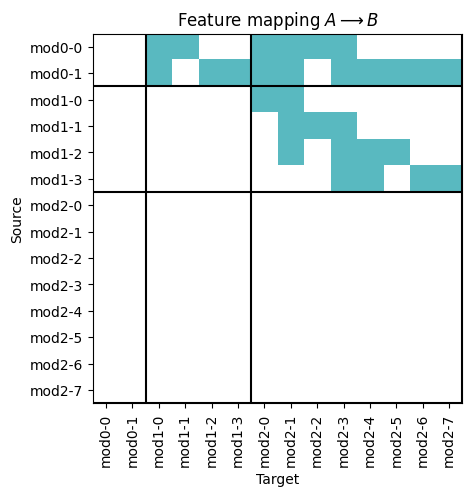

In [ ]:
ax = mdata.link.pl.adjacency_matrix(label=True)
ax.set(title="Feature mapping Source $\\longrightarrow$ Target")

This is equivalent to the following directed graph.

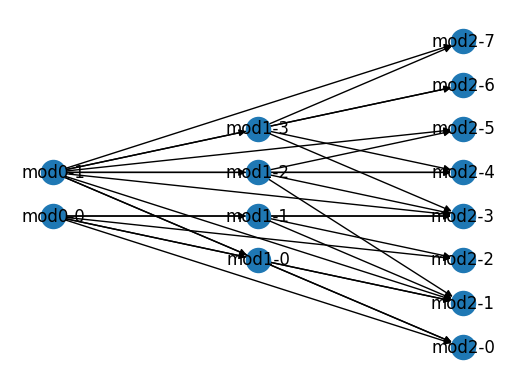

In [10]:
mdata.link.pl.graph(with_labels=True)

## Querying

We can use this graph to find related features. For example, we can find all features that downstream to feature 0 in modality 0 (`mod0-0`)

In [5]:
mdata.link.query_descendants(features=["mod0-0"])

View of MuData object with n_obs × n_vars = 5 × 7
  varp:	'feature_mapping'
  3 modalities
    mod0:	5 × 1
    mod1:	5 × 2
    mod2:	5 × 4

In [6]:
mdata.link.query_descendants(features=["mod0-0"], include_self=False)

View of MuData object with n_obs × n_vars = 5 × 6
  varp:	'feature_mapping'
  3 modalities
    mod0:	5 × 0
    mod1:	5 × 2
    mod2:	5 × 4

Equivalently, we can find all ancestors of a specific feature. 

In [7]:
mdata.link.query_ancestors(features=["mod2-1"])

View of MuData object with n_obs × n_vars = 5 × 6
  varp:	'feature_mapping'
  3 modalities
    mod0:	5 × 2
    mod1:	5 × 3
    mod2:	5 × 1

To get a specific modality level, you can use the standard `mudata` query:

In [8]:
subset = mdata.link.query_descendants(features=["mod0-0"])
subset.mod["mod0"].copy()

AnnData object with n_obs × n_vars = 5 × 1